# Rinha de Backend 2026 — Decision Tree para Detecção de Fraude

Notebook completo: EDA → tratamento → sweep de hiperparâmetros → treino → avaliação → uso.

Todas as funções pesadas vêm de `fraud_dt.py` (mesmo módulo usado em `train.py` e `predict.py`).

**Dataset:** 3.000.000 vetores rotulados de `resources/references.json.gz` (~284 MB descomprimido).  
Carregamos a versão pré-quantizada em `resources/vectors.bin` (int16, 87 MB) — 100× mais rápido.

**Objetivo:** treinar uma árvore que classifique uma transação como `fraud` ou `legit`, salvar o modelo e validá-lo nos exemplos da spec.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from fraud_dt import (
    load_dataset, dataset_stats, analyze_sentinels,
    fit_tree, fit_forest, sweep_hyperparams, evaluate,
    save_model, load_model, predict_samples, benchmark_inference,
    FEATURE_NAMES, FRAUD_THRESHOLD, SENTINEL_DIMS, SENTINEL_RAW,
)

sns.set_theme(context='notebook', style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

## 2. Carregar o dataset

`load_dataset` prefere o packed binary (int16 quantizado, scale=10000) e cai pro `.gz` se ausente.

In [2]:
X, y = load_dataset('../resources/vectors.bin', '../resources/references.json.gz')
print(f'shape: X={X.shape}, y={y.shape}, dtype={X.dtype}')

[load] packed binary ../resources/vectors.bin
[load] 3,000,000 vectors  fraud_rate=0.3331  (999,406 fraud / 2,000,594 legit)  in 0.4s
shape: X=(3000000, 14), y=(3000000,), dtype=float32


## 3. EDA — Análise exploratória

### 3.1. Schema, qualidade e balanço de classes

In [3]:
stats = dataset_stats(X, y)
print(f'rows: {stats["n_rows"]:,}  fraud_rate: {stats["fraud_rate"]:.4f}')
print(f'NaN? {stats["any_nan"]}  Inf? {stats["any_inf"]}')
feat_df = pd.DataFrame(stats['per_feature'])
feat_df

rows: 3,000,000  fraud_rate: 0.3331
NaN? False  Inf? False


,index,name,min,max,mean,std,legit_mean,fraud_mean,sentinel_rate
0,0,amount,0.0010,1.0000,0.211791,0.295325,0.029326,0.577045,0.000000
1,1,installments,0.0833,1.0000,0.359594,0.290947,0.173282,0.732549,0.000000
2,2,amount_vs_avg,0.0500,1.0000,0.367929,0.441987,0.064306,0.975718,0.000000
3,3,hour_of_day,0.0000,0.9565,0.457683,0.265552,0.608584,0.155611,0.000000
4,4,day_of_week,0.0000,1.0000,0.481316,0.308759,0.481472,0.481004,0.000000
5,5,minutes_since_last_tx,-1.0000,0.4993,-0.062418,0.490834,0.003878,-0.195129,0.199652
6,6,km_from_last_tx,-1.0000,1.0000,-0.038440,0.550910,-0.188536,0.262018,0.199652
7,7,km_from_home,0.0000,1.0000,0.213163,0.295963,0.030023,0.579769,0.000000
8,8,tx_count_24h,0.0500,1.0000,0.331524,0.281311,0.155866,0.683151,0.000000
9,9,is_online,0.0000,1.0000,0.464940,0.498769,0.305366,0.784372,0.000000


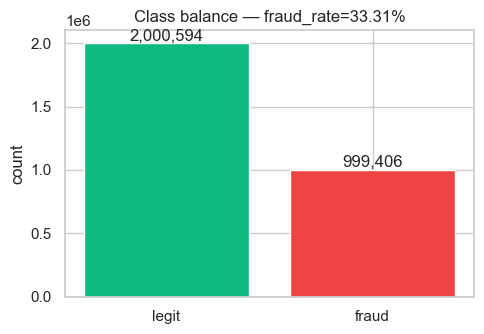

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
labels = ['legit', 'fraud']
counts = [stats['n_legit'], stats['n_fraud']]
bars = ax.bar(labels, counts, color=['#10b981', '#ef4444'])
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, c, f'{c:,}', ha='center', va='bottom')
ax.set_ylabel('count')
ax.set_title(f'Class balance — fraud_rate={stats["fraud_rate"]:.2%}')
plt.tight_layout(); plt.show()

### 3.2. Sentinela `-1` em dims 5 e 6

Os índices `minutes_since_last_tx` (5) e `km_from_last_tx` (6) recebem **`-1`** quando `last_transaction: null` (não existe histórico). É o único caso em que o vetor sai do intervalo `[0, 1]`. A spec diz **explicitamente para NÃO filtrar nem substituir** — o KNN agrupa naturalmente as transações sem histórico. Vamos verificar a distribuição.

{'rows_with_sentinel': 598957, 'rate': 0.19965233333333332, 'fraud_rate_within_sentinel': 0.33303559354010387, 'fraud_rate_outside_sentinel': 0.33316021412361213, 'dims_checked': [5, 6]}


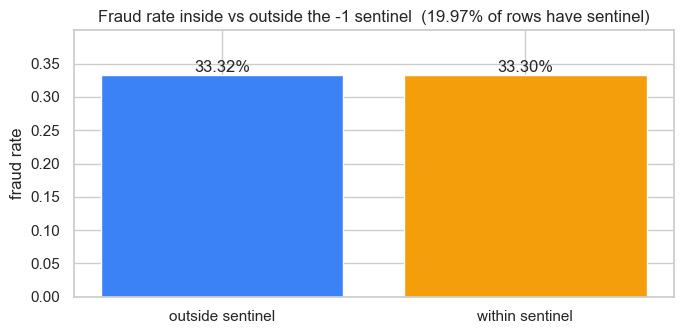

In [5]:
sent = analyze_sentinels(X, y)
print(sent)

fig, ax = plt.subplots(1, 1, figsize=(7, 3.5))
bar = ['outside sentinel', 'within sentinel']
vals = [sent['fraud_rate_outside_sentinel'], sent['fraud_rate_within_sentinel']]
ax.bar(bar, vals, color=['#3b82f6', '#f59e0b'])
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:.2%}', ha='center', va='bottom')
ax.set_ylim(0, max(vals) * 1.2)
ax.set_ylabel('fraud rate')
ax.set_title(f'Fraud rate inside vs outside the -1 sentinel  ({sent["rate"]:.2%} of rows have sentinel)')
plt.tight_layout(); plt.show()

### 3.3. Decisão de tratamento

**NÃO removemos nem imputamos os -1.** A spec é explícita; o KNN oracle do teste usa esses valores literais. Para o DT, valores -1 são apenas mais um número numérico que a árvore pode dividir — não há perda. Confirmamos apenas que não há NaN/Inf.

*Tratamento extra realizado:*
- ✓ Sem NaN / Inf
- ✓ Valores quantizados em scale 1/10000 (precisão 0.0001)  
- ✓ Split estratificado mantendo `fraud_rate` em treino e teste

### 3.4. Distribuição das features por classe

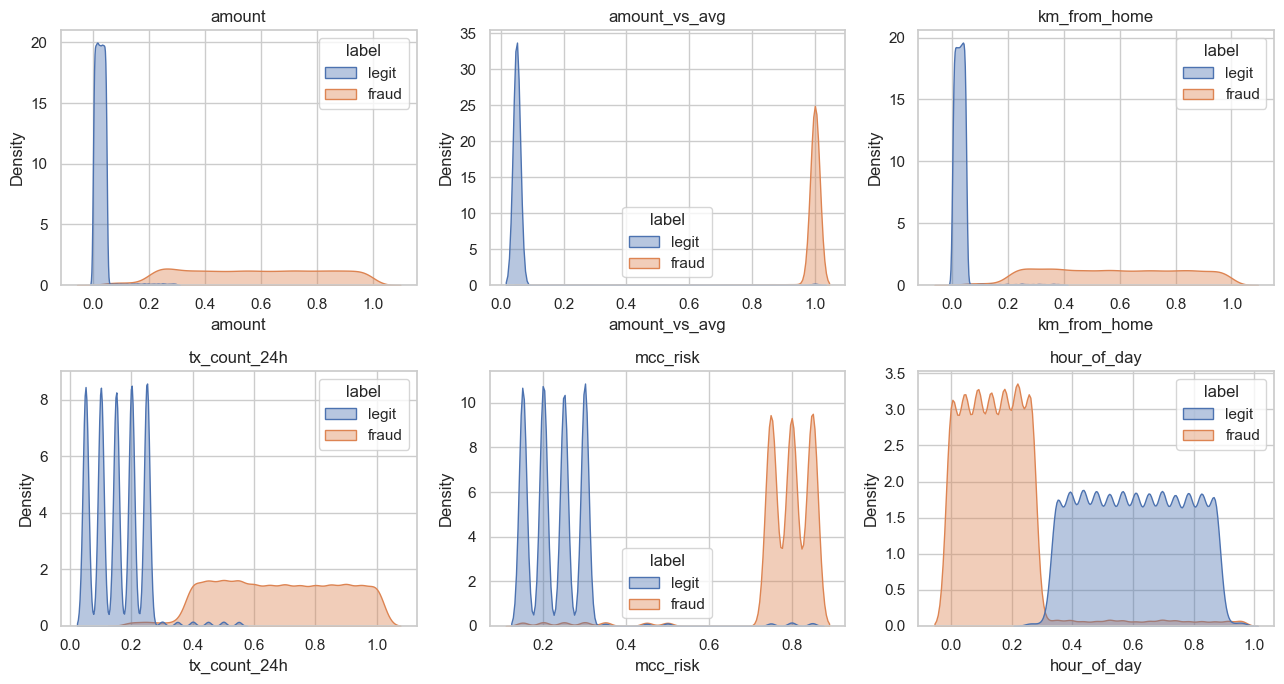

In [6]:
sample_idx = np.random.default_rng(0).choice(len(X), size=80_000, replace=False)
dfs = pd.DataFrame(X[sample_idx], columns=FEATURE_NAMES)
dfs['label'] = np.where(y[sample_idx] == 1, 'fraud', 'legit')

cols = ['amount', 'amount_vs_avg', 'km_from_home', 'tx_count_24h', 'mcc_risk', 'hour_of_day']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, cols):
    sns.kdeplot(data=dfs, x=col, hue='label', common_norm=False, ax=ax, fill=True, alpha=0.4)
    ax.set_title(col)
plt.tight_layout(); plt.show()

### 3.5. Correlação entre features

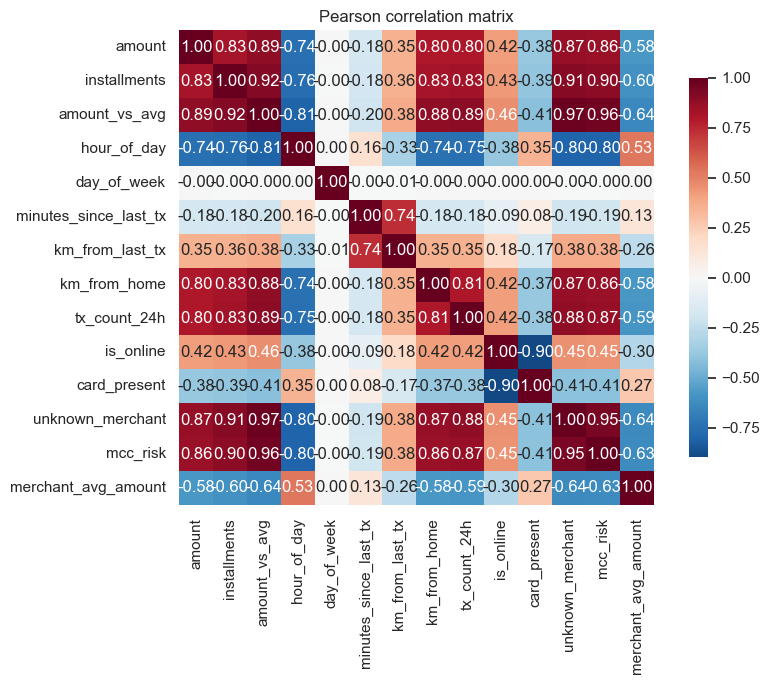

In [7]:
corr = pd.DataFrame(X[sample_idx], columns=FEATURE_NAMES).corr()
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Pearson correlation matrix')
plt.tight_layout(); plt.show()

## 4. Sweep de hiperparâmetros (3-fold CV)

Rodar k-fold CV em 3M de registros é lento (~minutos por configuração). Usamos uma amostra estratificada de 200k pra varrer `max_depth` rapidamente.

In [8]:
sweep = sweep_hyperparams(X, y, max_depths=(8, 12, 16, 20, 24, 28), min_samples_leaf=50, cv=3, sample=200_000)
sweep_df = pd.DataFrame(sweep)
sweep_df

  max_depth=  8  f1=0.9739 ± 0.0006  (5.91s)
  max_depth= 12  f1=0.9735 ± 0.0005  (4.39s)
  max_depth= 16  f1=0.9736 ± 0.0006  (4.55s)
  max_depth= 20  f1=0.9736 ± 0.0006  (4.77s)
  max_depth= 24  f1=0.9736 ± 0.0006  (4.57s)
  max_depth= 28  f1=0.9736 ± 0.0006  (4.15s)


,max_depth,f1_mean,f1_std,fit_seconds
0,8,0.973920,0.000604,5.91
1,12,0.973523,0.000508,4.39
2,16,0.973582,0.000579,4.55
3,20,0.973591,0.000617,4.77
4,24,0.973591,0.000617,4.57
5,28,0.973591,0.000617,4.15


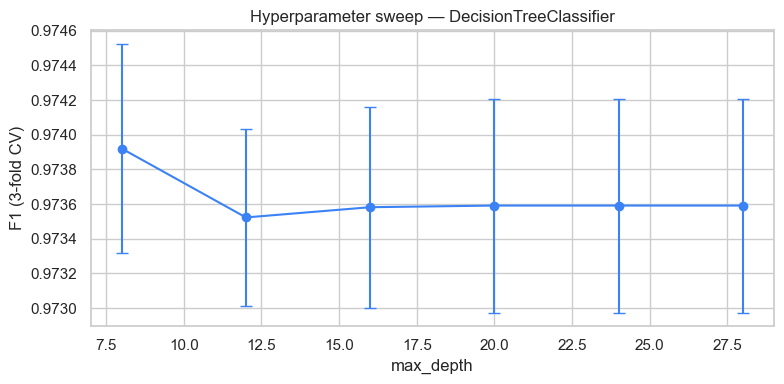

best max_depth: 8


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.errorbar(sweep_df['max_depth'], sweep_df['f1_mean'], yerr=sweep_df['f1_std'], marker='o', capsize=4, color='#3b82f6')
ax.set_xlabel('max_depth')
ax.set_ylabel('F1 (3-fold CV)')
ax.set_title('Hyperparameter sweep — DecisionTreeClassifier')
plt.tight_layout(); plt.show()

best_depth = int(sweep_df.sort_values('f1_mean').iloc[-1]['max_depth'])
print(f'best max_depth: {best_depth}')

## 5. Treino final

Treino completo nos 3M registros com o melhor `max_depth` do sweep.

In [10]:
res = fit_tree(X, y, max_depth=best_depth, min_samples_leaf=50)
metrics = evaluate(res.clf, res.X_test, res.y_test)

[split] train=2,400,000  test=600,000
[fit] DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, class_weight=None)
[fit] done in 14.3s  depth=8  leaves=96
[eval] accuracy=0.9826  f1=0.9739  auc=0.9993  (0.05µs/sample)
[eval] TN=394,720 FP=5,399 FN=5,055 TP=194,826


## 6. Baseline: Random Forest

Comparamos contra um RandomForest (50 árvores) — ensemble robusto para problemas tabulares. Treino e inferência são mais caros, mas serve como teto pra entender o quanto o DT está perto.

In [11]:
rf_res = fit_forest(X, y, n_estimators=50, max_depth=best_depth, min_samples_leaf=50)
rf_metrics = evaluate(rf_res.clf, rf_res.X_test, rf_res.y_test)

[fit] RandomForestClassifier(n_estimators=50, max_depth=8, min_samples_leaf=50)
[fit] done in 44.0s
[eval] accuracy=0.9826  f1=0.9739  auc=0.9993  (0.52µs/sample)
[eval] TN=395,209 FP=4,910 FN=5,505 TP=194,376


In [12]:
compare = pd.DataFrame([
    {'model': 'DT',  'accuracy': metrics['accuracy'],    'f1': metrics['f1'],    'auc': metrics['roc_auc'],    'inf_us': metrics['inference_us_per_sample']},
    {'model': 'RF',  'accuracy': rf_metrics['accuracy'], 'f1': rf_metrics['f1'], 'auc': rf_metrics['roc_auc'], 'inf_us': rf_metrics['inference_us_per_sample']},
])
compare

,model,accuracy,f1,auc,inf_us
0,DT,0.982577,0.973872,0.999309,0.0467
1,RF,0.982642,0.973908,0.999317,0.5168


## 7. Feature importance

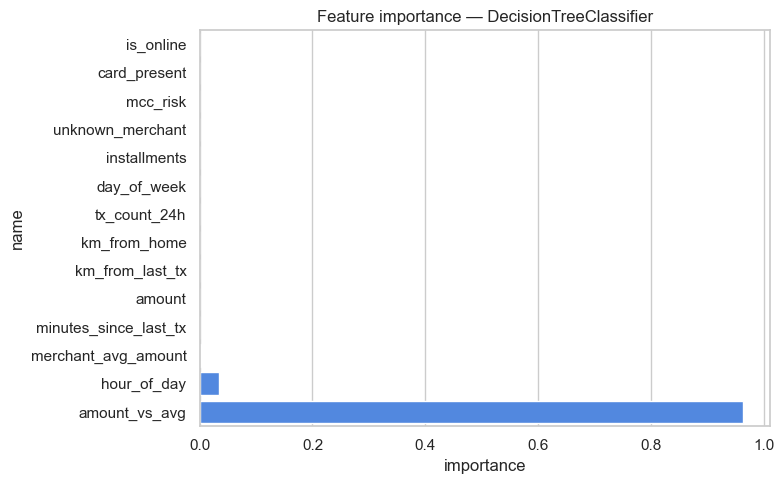

,index,name,importance
0,2,amount_vs_avg,0.962747
1,3,hour_of_day,0.034805
2,13,merchant_avg_amount,0.001853
3,5,minutes_since_last_tx,0.000433
4,0,amount,0.000052
5,6,km_from_last_tx,0.000036
6,7,km_from_home,0.000033
7,8,tx_count_24h,0.000012
8,4,day_of_week,0.000011
9,1,installments,0.000006


In [13]:
imp = pd.DataFrame(metrics['feature_importance']).sort_values('importance')
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
sns.barplot(data=imp, y='name', x='importance', color='#3b82f6', ax=ax)
ax.set_title('Feature importance — DecisionTreeClassifier')
plt.tight_layout(); plt.show()
imp[::-1]

## 8. Matriz de confusão + curvas

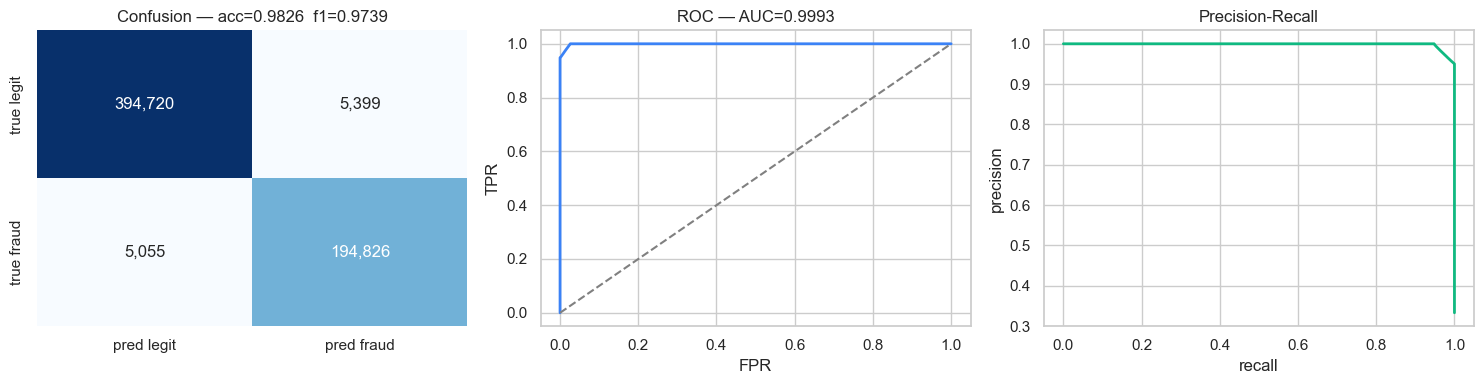

In [14]:
cm = metrics['confusion_matrix']
mat = np.array([[cm['tn'], cm['fp']], [cm['fn'], cm['tp']]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(mat, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['pred legit', 'pred fraud'], yticklabels=['true legit', 'true fraud'], ax=axes[0])
axes[0].set_title(f"Confusion — acc={metrics['accuracy']:.4f}  f1={metrics['f1']:.4f}")

axes[1].plot(metrics['roc_curve']['fpr'], metrics['roc_curve']['tpr'], color='#3b82f6', linewidth=2)
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f"ROC — AUC={metrics['roc_auc']:.4f}")

axes[2].plot(metrics['pr_curve']['recall'], metrics['pr_curve']['precision'], color='#10b981', linewidth=2)
axes[2].set_xlabel('recall'); axes[2].set_ylabel('precision')
axes[2].set_title('Precision-Recall')

plt.tight_layout(); plt.show()

## 9. Visualização dos primeiros níveis da árvore

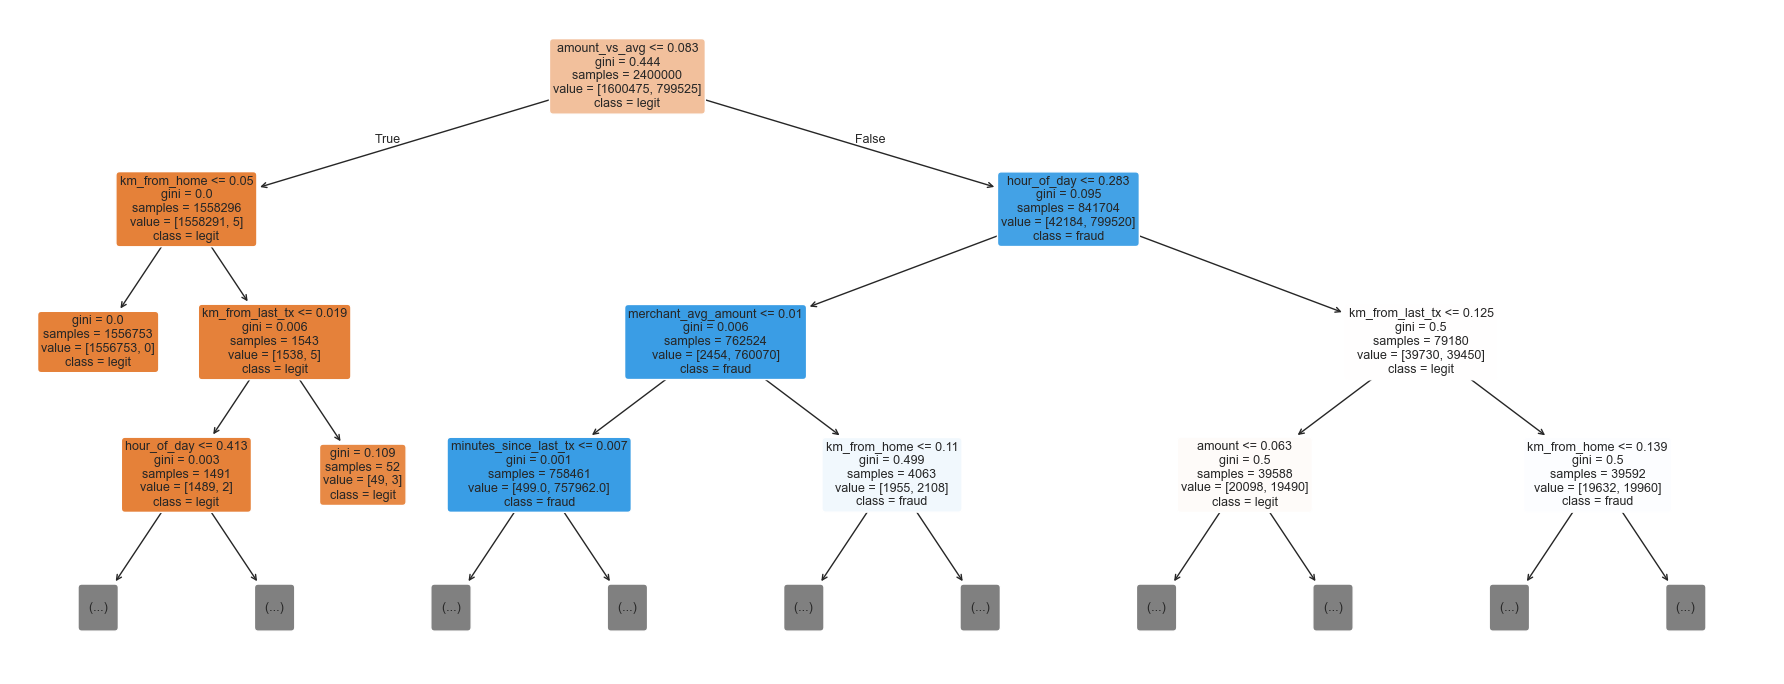

In [15]:
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(res.clf, max_depth=3, feature_names=FEATURE_NAMES, class_names=['legit', 'fraud'],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.tight_layout(); plt.show()

## 10. Salvar o modelo

In [16]:
out = save_model(res.clf, 'fraud_dt.joblib')
print(f'saved {out}  ({out.stat().st_size/1024:.1f} KB)')

saved fraud_dt.joblib  (7.3 KB)


## 11. Recarregar e testar nos exemplos da spec

Vetores tirados de `REGRAS_DE_DETECCAO.md`.

In [17]:
clf = load_model('fraud_dt.joblib')
samples = [
    {'name': 'spec/legit',  'vector': [0.0041, 0.1667, 0.05, 0.7826, 0.3333, -1, -1, 0.0292, 0.15, 0, 1, 0, 0.15, 0.006],  'expected': 'legit'},
    {'name': 'spec/fraud',  'vector': [0.9506, 0.8333, 1.0,  0.2174, 0.8333, -1, -1, 0.9523, 1.0,  0, 1, 1, 0.75, 0.0055], 'expected': 'fraud'},
]
pd.DataFrame(predict_samples(clf, samples, threshold=FRAUD_THRESHOLD))

,name,fraud_score,approved,expected
0,spec/legit,0.000000,True,legit
1,spec/fraud,0.999991,False,fraud


## 12. Microbenchmark de inferência (linha-a-linha, sem batching)

In [19]:
bench = benchmark_inference(clf, X, n=2000)
print(bench)

{'n': 2000, 'total_seconds': 0.336, 'us_per_sample': 167.93}
